In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [8]:
# 2. Load Dataset
num_words = 10000
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

In [9]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for word_index in sequence:
            if word_index < dimension:
                results[i, word_index] = 1.0
    return results

x_train = vectorize_sequences(x_train)
x_test = vectorize_sequences(x_test)

y_train = np.array(y_train).astype("float32")
y_test = np.array(y_test).astype("float32")

In [10]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7768 - loss: 0.5322 - val_accuracy: 0.8660 - val_loss: 0.3695
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9032 - loss: 0.2776 - val_accuracy: 0.8868 - val_loss: 0.2835
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9333 - loss: 0.1924 - val_accuracy: 0.8882 - val_loss: 0.2764
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9498 - loss: 0.1490 - val_accuracy: 0.8888 - val_loss: 0.2941
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9622 - loss: 0.1184 - val_accuracy: 0.8862 - val_loss: 0.3102
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9711 - loss: 0.0949 - val_accuracy: 0.8814 - val_loss: 0.3472
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9793 - loss: 0.0758 - val_accuracy: 0.8824 - val_loss: 0.3702
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9846 - loss: 0.0607 - val_accuracy: 0.8798 - v

In [14]:
results = model.evaluate(x_test, y_test)
print("Test Loss, Test Accuracy:", results)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8608 - loss: 0.5150
Test Loss, Test Accuracy: [0.514997661113739, 0.86080002784729]


In [15]:
def predict_review(review_vector):
    prediction = model.predict(review_vector)
    return "Positive 😊" if prediction[0][0] > 0.5 else "Negative 😞"

In [16]:
sample = x_test[0].reshape(1, -1)
print(predict_review(sample))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Negative 😞


In [17]:
import matplotlib.pyplot as plt

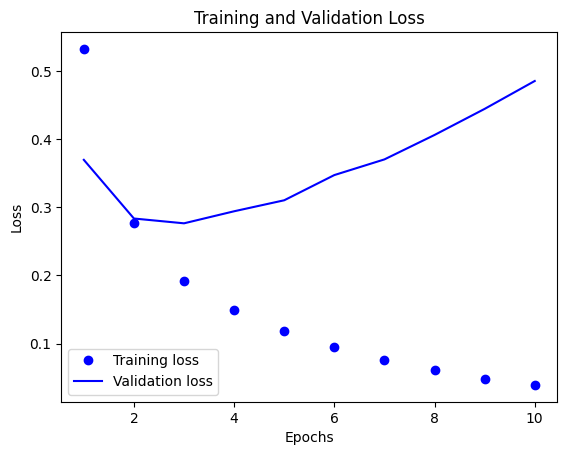

In [18]:
history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

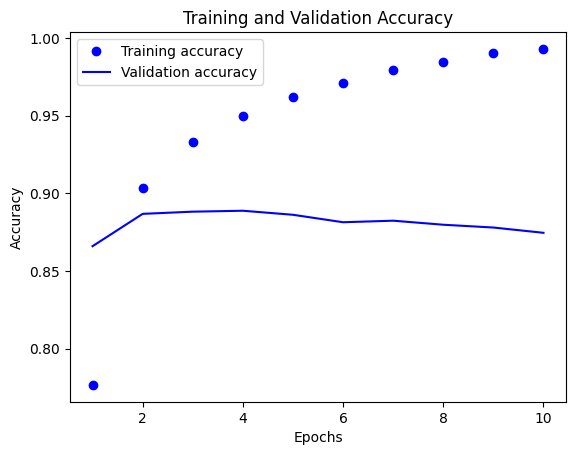

In [19]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()